In [1]:
from sklearn.datasets import make_classification

In [18]:
x, y = make_classification(
    n_samples=1000,           # Total number of samples (data points) to generate.
    n_redundant=0,            # Number of redundant features. Setting to 0 means all features are independent.
    n_features=2,
    n_clusters_per_class=1,   # Number of clusters (groups of samples) within each class. Setting to 1 means each class is a single cohesive group.
    weights=[0.90],           # Specifies the proportion of samples assigned to each class.
                              # Since only one weight (0.90) is given, it implies a two-class problem
                              # where the first class (Class 0) has 90% of the samples,
                              # and the second class (Class 1) has the remaining 10% (1.0 - 0.90).
                              # This creates an imbalanced dataset.
    random_state=2331         # Seed for the random number generator. Ensures that the generated dataset is the same every time the code is run (reproducibility).
)
# x will contain the features (the data points)
# y will contain the target variable (the class labels: 0 or 1)

In [19]:
import pandas as pd
# --- DataFrame Creation Step (Original) ---
df1 = pd.DataFrame(x, columns=['f1','f2'])
df2 = pd.DataFrame(y, columns=['target'])
final_df = pd.concat([df1, df2], axis=1)

# Display the head of the fixed DataFrame
print(final_df.head())

         f1        f2  target
0  1.225998 -0.894804       0
1  2.949017  0.441276       0
2  0.355538 -1.386905       0
3  1.134606 -1.055918       0
4  0.138230 -1.745908       0


In [21]:
final_df['target'].value_counts()

target
0    900
1    100
Name: count, dtype: int64

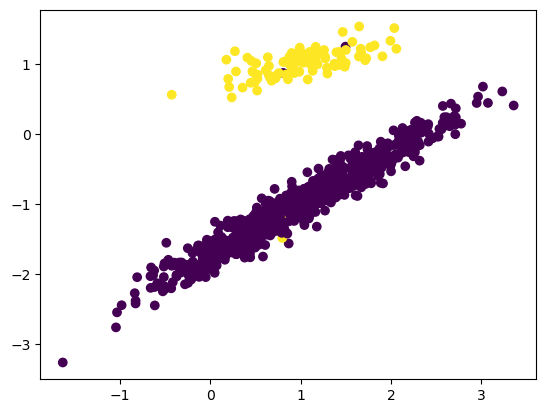

In [23]:
import matplotlib.pyplot as plt
plt.scatter(final_df['f1'],final_df['f2'],c=final_df['target'])

In [24]:
!pip install imblearn

In [25]:
from imblearn.over_sampling import SMOTE

In [27]:
## Transform the DATASET using SMOTE
oversample=SMOTE()
x,y=oversample.fit_resample(final_df[['f1','f2']],final_df['target'])

In [28]:
x.shape

(1800, 2)

In [30]:
y.shape

(1800,)

In [33]:
df1=pd.DataFrame(x,columns=['f1','f2'])
df2=pd.DataFrame(y,columns=['target'])
oversample_df=pd.concat([df1,df2],axis=1)

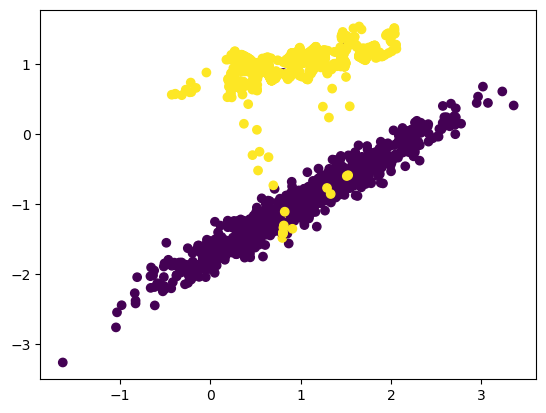

In [34]:
plt.scatter(oversample_df['f1'],oversample_df['f2'],c=oversample_df['target'])